## **TESTING SCRIPTS**

### **Test parameters**
Number of floorplans ``N = 10``

___

#### **``run_subset.py``**

**Total runtime: 89.647 seconds**

In [13]:
total_time = 4571/10 * 89.647

print(f"Expected time to run on all data: ", total_time/60, "mins\n", 
"                                 ", total_time/3600, "hours")

Expected time to run on all data:  682.9607283333335 mins
                                   11.382678805555559 hours


Profiling shows that the main bottleneck is the Jacobi update expression. 89.5128s of 89.647s are spent on the ``jacobi()`` function.

In particular, line 38 accounts for about 50.3% of the measured time, where the left-neighbor slice participates in the vectorized sum. However, this does not mean that only the left-neighbor access is inherently expensive by itself; rather, line profiling attributes much of the cost of the full multi-array expression to that line.

Significant time is also spent on lines 44–45, where masked indexing extracts the current and newly computed values at interior points, on line 47 where the maximum update difference is computed, and on line 48 where masked assignment writes values back into the grid.

The underlying issue is not that every array access duplicates the whole array. Ordinary slicing such as u[1:-1, :-2] usually creates a view, not a full copy. The expensive part is that the vectorized arithmetic and masked indexing create temporary arrays and involve substantial memory traffic. In particular, boolean indexing like ``u[1:-1, 1:-1][interior_mask]`` produces a copy of the selected elements, which is more memory-intensive and less cache-friendly.

___

### **``run_subset_5.py``**

#### **``--workers 1``**

In [14]:
total_time = 4571/10 * 93.801

print(f"Expected time to run on all data: ", total_time/60, "mins\n", 
"                                 ", total_time/3600, "hours")

Expected time to run on all data:  714.607285 mins
                                   11.910121416666668 hours


___

#### **``--workers 2``**

In [15]:
total_time = 4571/10 * 65.623

print(f"Expected time to run on all data: ", total_time/60, "mins\n", 
"                                 ", total_time/3600, "hours")

Expected time to run on all data:  499.93788833333343 mins
                                   8.33229813888889 hours


___

#### **``--workers 4``**

In [16]:
total_time = 4571/10 * 62.960

print(f"Expected time to run on all data: ", total_time/60, "mins\n", 
"                                 ", total_time/3600, "hours")

Expected time to run on all data:  479.6502666666667 mins
                                   7.994171111111112 hours


___

#### **``--workers 8``**

In [17]:
total_time = 4571/10 * 52.249

print(f"Expected time to run on all data: ", total_time/60, "mins\n", 
"                                 ", total_time/3600, "hours")

Expected time to run on all data:  398.0502983333334 mins
                                   6.63417163888889 hours


___

For small problem sizes such as 10 floorplans, increasing the worker count beyond 4 gives limited benefit, because each worker receives only one or two floorplans under static scheduling. In that regime, process-management overhead and load imbalance reduce the achievable speedup. Therefore, larger subsets such as 50 or 100 floorplans are more appropriate for measuring parallel scaling:

In [1]:
total_time_1 = 4571/100 * 1436.183
total_time_2 = 4571/100 * 910.024
total_time_3 = 4571/100 * 599.152
total_time_4 = 4571/100 * 474.474
total_time_5 = 4571/100 * 201.920
total_time_6 = 4571/100 * 220.770
total_time_7 = 4571/100 * 226.691

print(f"Expected time to run on all data (1 worker): ", total_time_1/60, "mins\n", 
"                                            ", total_time_1/3600, "hours")
print(f"Expected time to run on all data (2 workers): ", total_time_2/60, "mins\n", 
"                                             ", total_time_2/3600, "hours")
print(f"Expected time to run on all data (4 workers): ", total_time_3/60, "mins\n", 
"                                             ", total_time_3/3600, "hours")
print(f"Expected time to run on all data (8 workers): ", total_time_4/60, "mins\n", 
"                                             ", total_time_4/3600, "hours")
print(f"Expected time to run on all data (16 workers): ", total_time_5/60, "mins\n", 
"                                              ", total_time_5/3600, "hours")
print(f"Expected time to run on all data (32 workers): ", total_time_6/60, "mins\n", 
"                                              ", total_time_6/3600, "hours")
print(f"Expected time to run on all data (64 workers): ", total_time_7/60, "mins\n", 
"                                              ", total_time_7/3600, "hours")

Expected time to run on all data (1 worker):  1094.1320821666666 mins
                                              18.235534702777777 hours
Expected time to run on all data (2 workers):  693.2866173333333 mins
                                               11.554776955555555 hours
Expected time to run on all data (4 workers):  456.4539653333334 mins
                                               7.607566088888889 hours
Expected time to run on all data (8 workers):  361.470109 mins
                                               6.024501816666667 hours
Expected time to run on all data (16 workers):  153.82938666666666 mins
                                                2.563823111111111 hours
Expected time to run on all data (32 workers):  168.18994500000002 mins
                                                2.8031657500000002 hours
Expected time to run on all data (64 workers):  172.7007601666667 mins
                                                2.878346002777778 hours


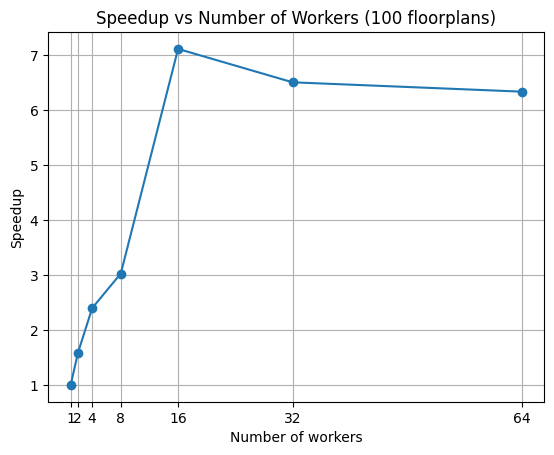

In [30]:
# Create speedup plot from provided data
import matplotlib.pyplot as plt

workers = [1, 2, 4, 8, 16, 32, 64]
times = [1436.183, 910.024, 599.152, 474.474, 201.920, 220.770, 226.691]

# Compute speedup relative to 1 worker
baseline = times[0]
speedup = [baseline / t for t in times]

plt.figure()
plt.plot(workers, speedup, marker='o')
plt.xlabel("Number of workers")
plt.ylabel("Speedup")
plt.title("Speedup vs Number of Workers (100 floorplans)")
plt.xticks(workers)
plt.grid()
plt.show()

#### **Amdahl's Law**

Amdahl's law says $$S_p = \frac{1}{(1-f) + \frac{f}{p}}$$ where $S_p$ is the measured speedup with $p$ workers, and $f$ is the parallel fraction.

The best **measured speedup** with 16 workers is $$S_{16} = \frac{T_1}{T_{16}} = \frac{1436.183}{201.920} \approx 7.11$$ We can then estimate the parallel fraction $f$ using Amdahl's law as follows:
$$
S_p = \frac{1}{(1 - f) + \frac{f}{p}}
\quad \Rightarrow \quad
\frac{1}{S_p} = 1 - f + \frac{f}{p}
\quad \Rightarrow \quad
\frac{1}{S_p} = 1 - f\left(1 - \frac{1}{p}\right)
$$

$$
f\left(1 - \frac{1}{p}\right) = 1 - \frac{1}{S_p}
\quad \Rightarrow \quad
f = \frac{1 - \frac{1}{S_p}}{1 - \frac{1}{p}} = \frac{1 - \frac{1}{7.11}}{1 - \frac{1}{16}} \approx 0.917
$$

So the estimated parallel fraction is about 91.7%, meaning roughly 92% of the program is parallelized and about 8.3% remains serial. The **theoretical maximum speedup** according to Amdahl's law is given by $$S_{\max} = \frac{1}{1-f} = \frac{1}{1-0.917} \approx 12.048$$

___

Using the best measured configuration of 16 workers, the observed speedup was $S_{16} = 7.11$. Applying Amdahl’s law gives an estimated parallel fraction of $f = 0.917$, meaning that roughly 92% of the computation is parallelized. This implies a theoretical maximum speedup of about $12\times$. Our measured best speedup of $7.11\times$ therefore corresponds to about 59% of the theoretical maximum. Increasing the worker count further to 32 reduced performance, indicating that overhead and resource contention outweighed the benefit of additional parallelism.

Using the fastest configuration of 16 workers, the runtime for 100 floorplans was measured to be approximately 202 seconds. Assuming linear scaling with respect to the number of floorplans, the total runtime for all 4571 buildings is estimated as:$$T_{all} = \frac{4571}{100} \cdot T_{100} = \frac{4571}{100} \cdot 201.92\,\text{s} = 9233\,\text{s}$$ which corresponds to approximately 154 minutes or 2.6 hours.

___

### **``run_subset_6.py``**

In [7]:
total_time_1 = 4571/100 * 1306.655
total_time_2 = 4571/100 * 659.302
total_time_3 = 4571/100 * 341.001
total_time_4 = 4571/100 * 209.744
total_time_5 = 4571/100 * 205.157
total_time_6 = 4571/100 * 226.313
total_time_7 = 4571/100 * 222.869

print(f"Expected time to run on all data (1 worker): ", total_time_1/60, "mins\n", 
"                                            ", total_time_1/3600, "hours")
print(f"Expected time to run on all data (2 workers): ", total_time_2/60, "mins\n", 
"                                             ", total_time_2/3600, "hours")
print(f"Expected time to run on all data (4 workers): ", total_time_3/60, "mins\n", 
"                                             ", total_time_3/3600, "hours")
print(f"Expected time to run on all data (8 workers): ", total_time_4/60, "mins\n", 
"                                             ", total_time_4/3600, "hours")
print(f"Expected time to run on all data (16 workers): ", total_time_5/60, "mins\n", 
"                                              ", total_time_5/3600, "hours")
print(f"Expected time to run on all data (32 workers): ", total_time_6/60, "mins\n", 
"                                              ", total_time_6/3600, "hours")
print(f"Expected time to run on all data (64 workers): ", total_time_7/60, "mins\n", 
"                                              ", total_time_7/3600, "hours")

Expected time to run on all data (1 worker):  995.4533341666667 mins
                                              16.590888902777778 hours
Expected time to run on all data (2 workers):  502.2782403333333 mins
                                               8.371304005555556 hours
Expected time to run on all data (4 workers):  259.7859285 mins
                                               4.329765474999999 hours
Expected time to run on all data (8 workers):  159.78997066666668 mins
                                               2.6631661777777778 hours
Expected time to run on all data (16 workers):  156.29544116666668 mins
                                                2.6049240194444447 hours
Expected time to run on all data (32 workers):  172.41278716666665 mins
                                                2.8735464527777776 hours
Expected time to run on all data (64 workers):  169.78903316666668 mins
                                                2.8298172194444446 hours


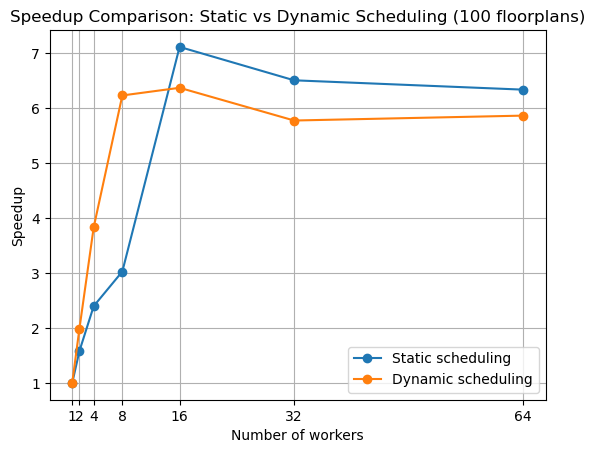

In [ ]:
# Plot comparison between static (Task 5) and dynamic (Task 6)
import matplotlib.pyplot as plt

# Workers
workers = [1, 2, 4, 8, 16, 32, 64]

# Static (Task 5) times
times_static = [1436.183, 910.024, 599.152, 474.474, 201.920, 220.770, 226.691]

# Dynamic (Task 6) times
times_dynamic = [1306.655, 659.302, 341.001, 209.744, 205.157, 226.313, 222.869]

# Compute speedups
baseline_static = times_static[0]
baseline_dynamic = times_dynamic[0]

speedup_static = [baseline_static / t for t in times_static]
speedup_dynamic = [baseline_dynamic / t for t in times_dynamic]

# Plot
plt.figure()
plt.plot(workers, speedup_static, marker='o', label='Static scheduling')
plt.plot(workers, speedup_dynamic, marker='o', label='Dynamic scheduling')

plt.xlabel("Number of workers")
plt.ylabel("Speedup")
plt.title("Speedup Comparison: Static vs Dynamic Scheduling (100 floorplans)")
plt.xticks(workers)
plt.legend()
plt.grid()
plt.show()

Dynamic scheduling significantly improves performance compared to static scheduling for small to moderate numbers of workers. Floorplans require different numbers of Jacobi iterations to converge, leading to load imbalance in the static case where workers are assigned fixed subsets. With dynamic scheduling, workers receive new floorplans as soon as they finish their current task, reducing idle time and improving resource utilization. For larger numbers of workers, the performance difference between the two approaches diminishes, as overhead and hardware limitations such as memory bandwidth become the dominant factors.

The results clearly demonstrate that dynamic scheduling mitigates load imbalance, particularly at lower worker counts, resulting in significantly higher speedups compared to static scheduling.

___

#### **``run_subset_7.py``**


In [9]:
total_time = 4571/100 * 52.980

print(f"Expected time to run on all data: ", total_time/60, "mins\n", 
"                                 ", total_time/3600, "hours")

Expected time to run on all data:  40.36193 mins
                                   0.6726988333333334 hours


a) There is a considerable speedup. Using dynamic scheduling's best performing number of workers (8), we see a

#### **``run_subset_8.py``**

This solution implements the Jacobi solver on the GPU using a custom CUDA kernel with Numba.

- **Kernel design:** a 2D grid where each thread updates one interior cell `(i, j)` (mapped to the padded grid at `(i+1, j+1)`). If `interior_mask[i, j]` is true, the thread writes the Jacobi average of the four neighbors; otherwise it copies the old value so walls/exterior stay unchanged.
- **Synchronization between iterations:** the kernel performs **one** Jacobi iteration. The host launches the kernel `max_iter` times and swaps the two device buffers between launches; the launch boundary provides the global synchronization.
- **Stopping criterion:** early stopping (`atol`) is **skipped**; we run a fixed number of iterations to match the exercise requirements.

To validate correctness, `run_subset_8.py` supports `--verify`, which compares CUDA vs NumPy (fixed-iteration) on one building and checks the maximum absolute difference.


In [1]:
from pathlib import Path

N_total = 4571
N_subset = 20

DEFAULT_T_CUDA = 6.741
DEFAULT_T_NUMPY = 127.302

def read_total_runtime(path: str):
    p = Path(path)
    if not p.exists():
        return None
    lines = p.read_text().splitlines()
    for line in reversed(lines):
        if line.startswith('# Total runtime:'):  # '# Total runtime: X seconds'
            return float(line.split(':', 1)[1].strip().split()[0])
    return None

T_cuda = read_total_runtime('cuda_20.csv')
T_numpy = read_total_runtime('numpy_20.csv')

if T_cuda is None or T_numpy is None:
    print('NOTE: cuda_20.csv / numpy_20.csv not found (or missing runtime lines). Using example numbers.')
    T_cuda = DEFAULT_T_CUDA
    T_numpy = DEFAULT_T_NUMPY

speedup = T_numpy / T_cuda
T_all_cuda_s = T_cuda * (N_total / N_subset)

print(f'CUDA runtime ({N_subset} buildings): {T_cuda:.3f} s')
print(f'NumPy runtime ({N_subset} buildings): {T_numpy:.3f} s')
print(f'Speedup (NumPy / CUDA): {speedup:.2f}x')
print(f'Estimated CUDA time for all {N_total} buildings: {T_all_cuda_s/60:.2f} min ({T_all_cuda_s/3600:.2f} h)')


CUDA runtime (20 buildings): 7.238 s
NumPy runtime (20 buildings): 135.248 s
Speedup (NumPy / CUDA): 18.69x
Estimated CUDA time for all 4571 buildings: 27.57 min (0.46 h)
